# **RQ2**: Dynamic Community Detection

In [40]:
import os
import igraph as ig
import leidenalg

In [42]:
import json

for i in range(1, 11):
    print(f'\nAnalyzing graph of snapshot {i}')
    file = os.path.join('igraph_graphs', f'graph_snap{i}_p99.igp')
    g = ig.Graph.Read_Pickle(file)
    
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights='weight',
        resolution_parameter=1.0
    )
    print(f'\tCorrectly ran Leiden CD')
    
    print(f'\t#comms: {len(partition)}')

    communities = list()
    
    for j, com in enumerate(partition):
        print(f'\t\t{len(com)}')
        communities.append(list())
        for node in com:
            communities[j].append(g.vs[node]['token'])

    out = os.path.join('leiden_clusterings', f'clust_snap{i}.json')
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(communities, f)


Analyzing graph of snapshot 1
	Correctly ran Leiden CD
	#comms: 8
		15126
		8890
		8677
		6302
		6000
		2763
		1238
		464

Analyzing graph of snapshot 2
	Correctly ran Leiden CD
	#comms: 7
		16962
		9443
		7095
		6169
		3745
		3488
		287

Analyzing graph of snapshot 3
	Correctly ran Leiden CD
	#comms: 8
		21283
		12815
		10406
		7776
		6957
		3183
		1112
		655

Analyzing graph of snapshot 4
	Correctly ran Leiden CD
	#comms: 7
		15904
		11050
		10797
		8925
		8778
		8619
		558

Analyzing graph of snapshot 5
	Correctly ran Leiden CD
	#comms: 11
		19917
		12136
		11197
		10329
		9517
		7427
		2596
		1202
		600
		565
		2

Analyzing graph of snapshot 6
	Correctly ran Leiden CD
	#comms: 10
		17443
		13746
		13676
		12303
		7685
		6115
		4572
		2789
		2439
		2058

Analyzing graph of snapshot 7
	Correctly ran Leiden CD
	#comms: 9
		11577
		11323
		9842
		9178
		8354
		7411
		2472
		2175
		1855

Analyzing graph of snapshot 8
	Correctly ran Leiden CD
	#comms: 7
		19577
		13054
		9852
		7023
		3

In [ ]:
import json

for i in range(1, 11):
    print(f'\nAnalyzing graph of snapshot {i}')
    file = os.path.join('igraph_graphs', f'graph_snap{i}_p99.igp')
    g = ig.Graph.Read_Pickle(file)
    
    partition = g.community_infomap(
        edge_weights='weight'
    )

    print(f'\tCorrectly ran Infomap CD')
    
    print(f'\t#comms: {len(partition)}')

    communities = list()
    
    for j, com in enumerate(partition):
        # print(f'\t\t{len(com)}')
        communities.append(list())
        for node in com:
            communities[j].append(g.vs[node]['token'])

    out = os.path.join('infomap_clusterings', f'clust_snap{i}.json')
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(communities, f)


Analyzing graph of snapshot 1
	Correctly ran Infomap CD
	#comms: 87

Analyzing graph of snapshot 2
	Correctly ran Infomap CD
	#comms: 79

Analyzing graph of snapshot 3
	Correctly ran Infomap CD
	#comms: 114

Analyzing graph of snapshot 4
	Correctly ran Infomap CD
	#comms: 107

Analyzing graph of snapshot 5
	Correctly ran Infomap CD
	#comms: 79

Analyzing graph of snapshot 6
	Correctly ran Infomap CD
	#comms: 68

Analyzing graph of snapshot 7
	Correctly ran Infomap CD
	#comms: 76

Analyzing graph of snapshot 8
	Correctly ran Infomap CD
	#comms: 83

Analyzing graph of snapshot 9
	Correctly ran Infomap CD
	#comms: 64

Analyzing graph of snapshot 10
	Correctly ran Infomap CD
	#comms: 107


## Leiden communities comparison by snapshots

In [363]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import numpy as np

In [364]:
def overlap_coeff(com1: list, com2: list) -> float:
    """
    Calculate Overlap Coefficient between two communities.
        
    ---
    
    Args:
        com1 (list): First community
        com2 (list): Second community
    
    Returns:
        float: Float representing the Overlap Coefficient
    """
    set1, set2 = set(com1), set(com2)
    return len(set1 & set2) / min(len(set1), len(set2))


def compare_partitions(part_prev: list, part_cur: str) -> list:
    """
    Compare two partitions (lists of communities) from consecutive snapshots by computing
    the Jaccard similarity between each pair of communities.

    Args:
        snap_prev (str): Path to the JSON file containing the previous snapshot's partition.
        snap_cur (str): Path to the JSON file containing the current snapshot's partition.

    Returns:
        list: A matrix (list of lists) where each element [i][j] is the Overlap Coefficient
              between the i-th community in the current snapshot and the j-th community in the previous snapshot.
    """
    sim_matrix = np.zeros((len(part_cur), len(part_prev)))
    for i, com_cur in enumerate(part_cur):
        for j, com_prev in enumerate(part_prev):
            jaccard = overlap_coeff(com_cur, com_prev)
            sim_matrix[i][j] = jaccard
            
    return sim_matrix

In [365]:
sim_matrices = list()
community_sizes = list()

for i in range(1, 11):
    file = os.path.join('leiden_clusterings', f'clust_snap{i}.json')
    if i > 1:
        part_prev = part_cur
    with open(file, 'r', encoding='utf-8') as f:
        part_cur = json.load(f)
    
    community_sizes.append(list())
    
    for com in part_cur:
        community_sizes[-1].append(len(com))
    
    if i == 1:
        continue
    
    matrix = compare_partitions(part_prev=part_prev, part_cur=part_cur)
    sim_matrices.append(matrix)
    
    print(f'\nSnapshot {i} w.r.t. snapshot {i-1} (shape: {matrix.shape}):')
    for j, row in enumerate(matrix):
        print(f'\tCommunity {j}:')
        print(f'\t\tmax JS: {np.max(row)}')
        print(f'\t\tmax JS: {np.argmax(row)}')


Snapshot 2 w.r.t. snapshot 1 (shape: (7, 8)):
	Community 0:
		max JS: 0.7318524395081317
		max JS: 0
	Community 1:
		max JS: 0.6134983127109112
		max JS: 1
	Community 2:
		max JS: 0.6105
		max JS: 4
	Community 3:
		max JS: 0.5851839844383206
		max JS: 3
	Community 4:
		max JS: 0.5883620689655172
		max JS: 7
	Community 5:
		max JS: 0.5964531306550851
		max JS: 5
	Community 6:
		max JS: 0.5365853658536586
		max JS: 0

Snapshot 3 w.r.t. snapshot 2 (shape: (8, 7)):
	Community 0:
		max JS: 0.7856384860275911
		max JS: 0
	Community 1:
		max JS: 0.7142857142857143
		max JS: 6
	Community 2:
		max JS: 0.7025449829794131
		max JS: 3
	Community 3:
		max JS: 0.5667371388301621
		max JS: 2
	Community 4:
		max JS: 0.5636849132176235
		max JS: 4
	Community 5:
		max JS: 0.5039271127866792
		max JS: 5
	Community 6:
		max JS: 0.4037769784172662
		max JS: 0
	Community 7:
		max JS: 0.5038167938931297
		max JS: 4

Snapshot 4 w.r.t. snapshot 3 (shape: (7, 8)):
	Community 0:
		max JS: 0.5777162977867203
		m

In [366]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_temporal_community_similarity(sim_matrices,
                                       community_sizes,
                                       threshold=0.5,
                                       x_spacing=3.0,
                                       y_spacing=1.0,
                                       node_size=100,
                                       clustering='Leiden'):

    G = nx.DiGraph()

    # --- build graph ---
    for t, sim in enumerate(sim_matrices):
        n_curr, n_prev = sim.shape

        for i in range(n_prev):
            if community_sizes[t][i] > 50:
                G.add_node((t, i), snapshot=t, size=community_sizes[t][i])

        for j in range(n_curr):
            if community_sizes[t+1][j] > 50:
                G.add_node((t + 1, j), snapshot=t + 1, size=community_sizes[t + 1][j])

        for i in range(n_prev):
            for j in range(n_curr):
                w = sim[j, i]
                if (w >= threshold and
                    community_sizes[t][i] > 50 and
                    community_sizes[t + 1][j] > 50):
                    G.add_edge((t, i), (t + 1, j), weight=w, label=f"{w:.2f}")

    # --- layered layout (robust) ---
    pos = {}
    layers = {}

    for n in G.nodes():
        snapshot = G.nodes[n].get("snapshot", None)
        if snapshot is None:
            raise ValueError(f"Node {n} has no snapshot attribute")
        layers.setdefault(snapshot, []).append(n)

    for t in sorted(layers):
        for idx, n in enumerate(sorted(layers[t])):
            pos[n] = (t * x_spacing, -idx * y_spacing)

    # --- plotting ---
    # plt.figure(figsize=(12, 8))
    _, ax = plt.subplots(figsize=(18, 10))
    
    node_colors = []

    for n in G.nodes():
        indeg = G.in_degree(n)
        outdeg = G.out_degree(n)

        if n[0] == 0:
            node_colors.append("black" if outdeg > 0 else 'red')
            continue
        if n[0] == 9:
            node_colors.append("black" if indeg > 0 else 'green')
            continue

        if indeg == 0 and outdeg > 0:
            node_colors.append("green")   # no predecessors
        elif indeg > 0 and outdeg == 0:
            node_colors.append("red")     # no successors
        else:
            node_colors.append("black")   # internal or isolated


    # draw nodes with constant size
    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_size,
        node_color=node_colors,
        alpha=0.8
    )

    # draw node cardinality above nodes
    node_labels = {
        n: str(G.nodes[n]["size"])
        for n in G.nodes()
    }

    # shift labels upward slightly
    label_pos = {
        n: (pos[n][0], pos[n][1] + 0.3)
        for n in pos
    }

    nx.draw_networkx_labels(
        G,
        label_pos,
        labels=node_labels,
        font_size=10
    )

    weights = [G[u][v]["weight"] for u, v in G.edges()]

    norm = mcolors.Normalize(vmin=min(weights), vmax=max(weights))
    cmap = cm.plasma  # perceptually uniform
    
    nx.draw_networkx_edges(
        G, pos,
        edge_color=weights,
        edge_cmap=cmap,
        edge_vmin=norm.vmin,
        edge_vmax=norm.vmax,
        alpha=0.6
    )
    
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    plt.colorbar(sm, ax=ax, label="Community similarity")

    plt.title(f'Evolution of {clustering}-detected communities',
              fontsize=20)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
            label='New community',
            markerfacecolor='green', markersize=6),

        Line2D([0], [0], marker='o', color='w',
            label='Sink',
            markerfacecolor='red', markersize=6)
    ]

    plt.legend(
        handles=legend_elements,
        loc='lower right',
        frameon=False
    )


    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [367]:
[len(com) for com in sim_matrices]

[7, 8, 7, 11, 10, 9, 7, 8, 9]

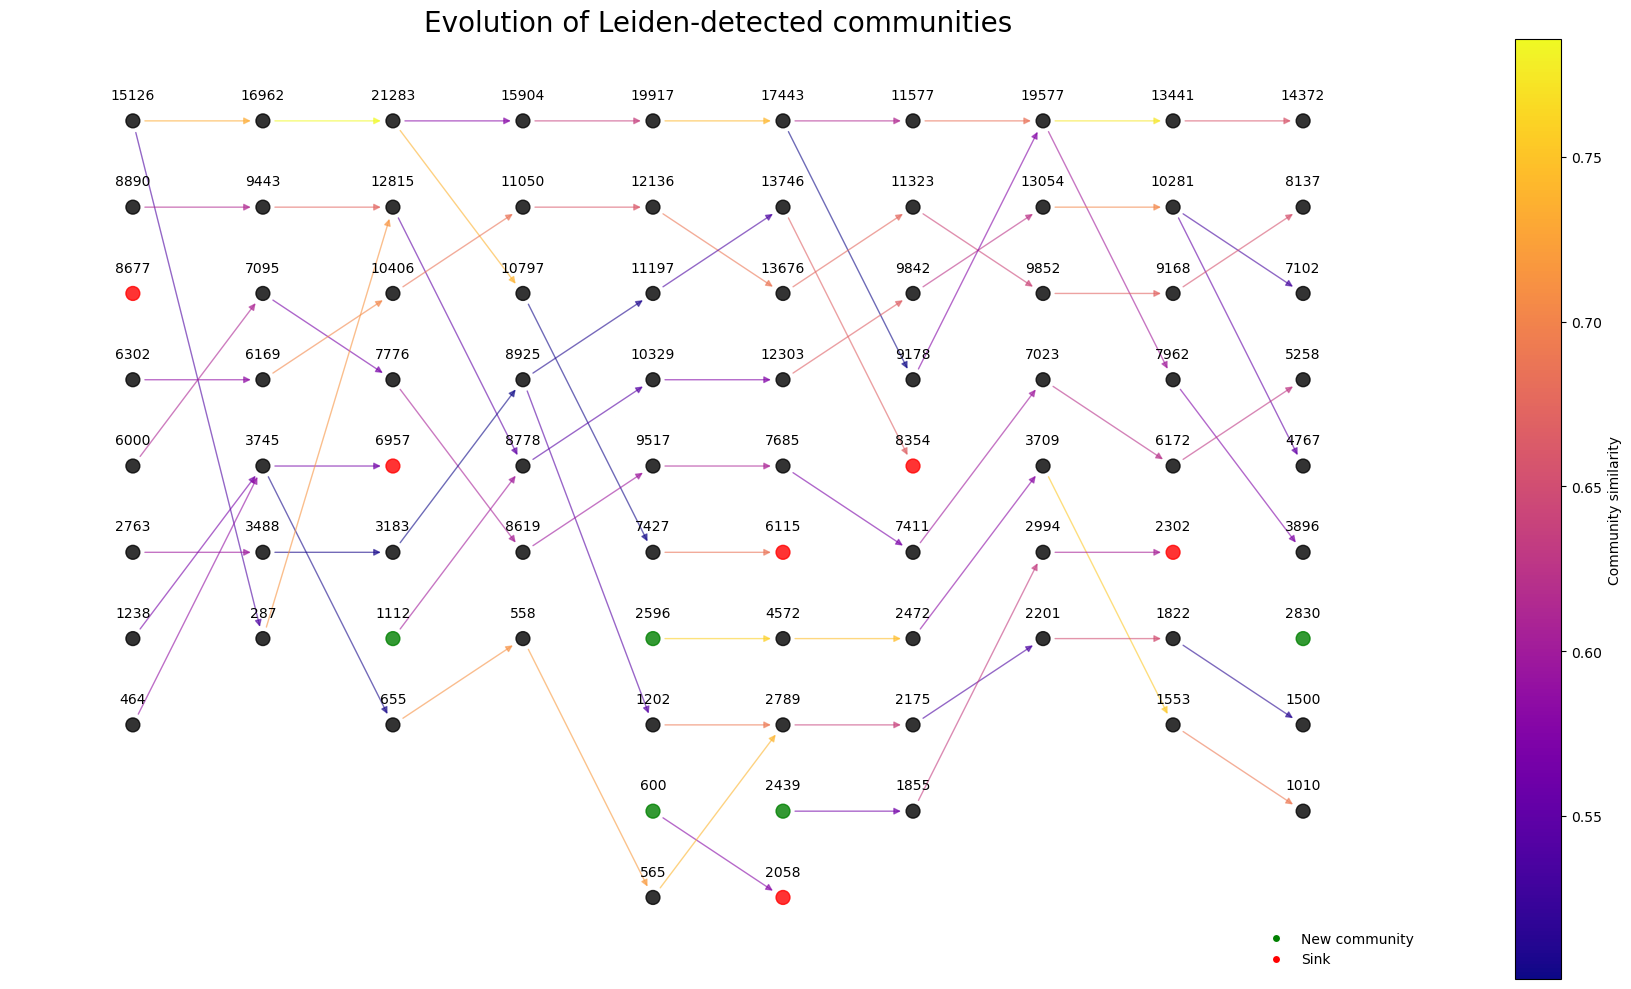

In [368]:
plot_temporal_community_similarity(sim_matrices, community_sizes)

## Infomap communities comparison by snapshot

In [369]:
sim_matrices = list()
community_sizes = list()

for i in range(1, 11):
    file = os.path.join('infomap_clusterings', f'clust_snap{i}.json')
    if i > 1:
        part_prev = part_cur
    with open(file, 'r', encoding='utf-8') as f:
        part_cur = json.load(f)
    
    community_sizes.append(list())
    
    for com in part_cur:
        community_sizes[-1].append(len(com))
    
    if i == 1:
        continue
    
    matrix = compare_partitions(part_prev=part_prev, part_cur=part_cur)
    sim_matrices.append(matrix)
    
    print(f'\nSnapshot {i} w.r.t. snapshot {i-1} (shape: {matrix.shape}):')
    for j, row in enumerate(matrix):
        print(f'\tCommunity {j}:')
        print(f'\t\tmax JS: {np.max(row)}')
        print(f'\t\tmax JS: {np.argmax(row)}')


Snapshot 2 w.r.t. snapshot 1 (shape: (79, 87)):
	Community 0:
		max JS: 0.5036231884057971
		max JS: 15
	Community 1:
		max JS: 0.42857142857142855
		max JS: 34
	Community 2:
		max JS: 0.5591397849462365
		max JS: 4
	Community 3:
		max JS: 0.75
		max JS: 67
	Community 4:
		max JS: 0.75
		max JS: 23
	Community 5:
		max JS: 1.0
		max JS: 78
	Community 6:
		max JS: 0.7657142857142857
		max JS: 16
	Community 7:
		max JS: 0.6054177545691906
		max JS: 7
	Community 8:
		max JS: 0.4199706314243759
		max JS: 8
	Community 9:
		max JS: 0.5641461342395921
		max JS: 3
	Community 10:
		max JS: 0.5920471281296024
		max JS: 12
	Community 11:
		max JS: 0.23856858846918488
		max JS: 2
	Community 12:
		max JS: 0.5581395348837209
		max JS: 9
	Community 13:
		max JS: 0.375
		max JS: 73
	Community 14:
		max JS: 0.6638655462184874
		max JS: 0
	Community 15:
		max JS: 0.5
		max JS: 76
	Community 16:
		max JS: 0.655705996131528
		max JS: 17
	Community 17:
		max JS: 0.7014010507880911
		max JS: 2
	Community 18

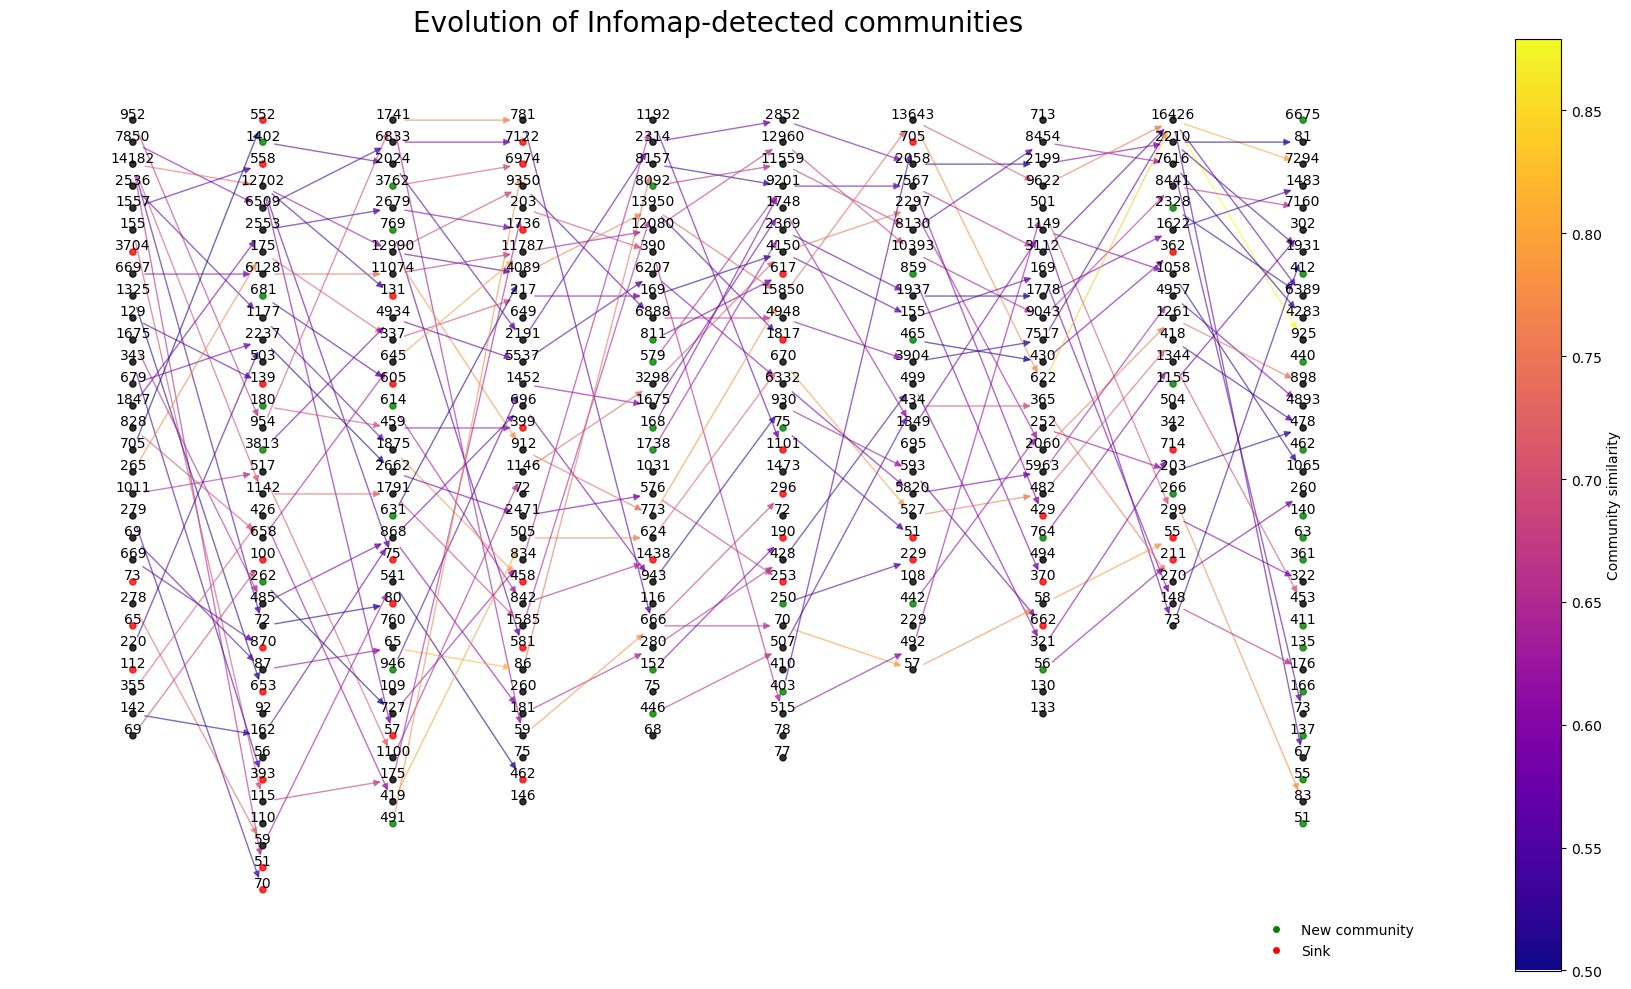

In [370]:
plot_temporal_community_similarity(sim_matrices, community_sizes, node_size=20, clustering='Infomap')